# X-ray CT Tooth Reconstruction

This notebook demonstrates the reconstruction of a tooth cross-section from parallel-beam X-ray transmission projections using **Filtered Back-Projection (FBP)**.

**Pipeline:**
1. Load raw detector data (projections, flat/dark fields, angles)
2. Flat-field correction and log-linearization (Beer-Lambert law)
3. Rotation center estimation via cross-correlation
4. Filtered back-projection with ramp (Ram-Lak) filter
5. Comparison against gridrec baseline

The notebook loads precomputed results from `evaluation/reference_outputs/` for fast visualization. Commented-out code shows how to run the full pipeline from scratch.

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

TASK_DIR = os.path.dirname(os.getcwd())
sys.path.insert(0, TASK_DIR)

from src.preprocessing import load_observation, load_metadata, normalize, minus_log
from src.physics_model import find_rotation_center, _shift_sinogram
from src.solvers import filtered_back_projection, circular_mask
from src.visualization import compute_metrics, plot_sinogram, plot_reconstruction

## 1. Load and Inspect Data

The dataset is from APS beamline 2-BM/32-ID: 181 X-ray projections of a tooth specimen spanning 0 to ~pi radians, with 640 detector pixels per projection and 2 sinogram rows.

In [2]:
data_dir = os.path.join(TASK_DIR, "data")
obs = load_observation(data_dir)
meta = load_metadata(data_dir)

print(f"Projections:  {obs['projections'].shape} (n_angles, n_sino, n_det)")
print(f"Flat fields:  {obs['flat_field'].shape}")
print(f"Dark fields:  {obs['dark_field'].shape}")
print(f"Angles:       {obs['theta'].shape}, range [{obs['theta'][0]:.3f}, {obs['theta'][-1]:.3f}] rad")
print(f"\nMetadata: {meta}")

Projections:  (181, 2, 640) (n_angles, n_sino, n_det)
Flat fields:  (10, 2, 640)
Dark fields:  (10, 2, 640)
Angles:       (181,), range [0.000, 3.124] rad

Metadata: {'n_projections': 181, 'n_sinograms': 2, 'n_detector_pixels': 640, 'n_flat_fields': 10, 'n_dark_fields': 10, 'theta_min_rad': 0.0, 'theta_max_rad': 3.124235788100347, 'modality': 'x-ray_transmission_ct'}


## 2. Preprocessing

**Flat-field correction** converts raw detector counts to transmission:
$$T = \frac{I_{\text{proj}} - I_{\text{dark}}}{I_{\text{flat}} - I_{\text{dark}}}$$

**Log-linearization** (Beer-Lambert law) converts transmission to line integrals of attenuation:
$$\text{sinogram} = -\ln(T)$$

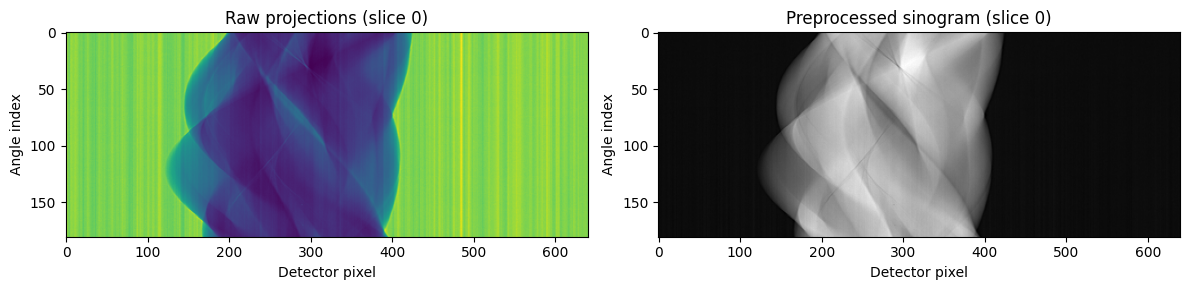

Sinogram shape: (181, 2, 640)
Value range: [-0.0976, 1.9539]


In [3]:
# --- Uncomment to run preprocessing from scratch ---
# proj_norm = normalize(obs['projections'], obs['flat_field'], obs['dark_field'])
# sinogram_data = minus_log(proj_norm)

# Load precomputed sinogram from reference outputs
sinogram_data = np.load(os.path.join(TASK_DIR, "evaluation", "reference_outputs", "sinogram.npy"))

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].imshow(obs['projections'][:, 0, :], aspect='auto')
axes[0].set_title("Raw projections (slice 0)")
axes[0].set_xlabel("Detector pixel"); axes[0].set_ylabel("Angle index")

axes[1].imshow(sinogram_data[:, 0, :], aspect='auto', cmap='gray')
axes[1].set_title("Preprocessed sinogram (slice 0)")
axes[1].set_xlabel("Detector pixel"); axes[1].set_ylabel("Angle index")
plt.tight_layout()
plt.show()

print(f"Sinogram shape: {sinogram_data.shape}")
print(f"Value range: [{sinogram_data.min():.4f}, {sinogram_data.max():.4f}]")

## 3. Rotation Center Estimation

For parallel-beam CT, projections at angles $\theta$ and $\theta + \pi$ are mirror images of each other. The shift between the first projection and the flipped last projection reveals the rotation center offset.

In [4]:
# --- Uncomment to find rotation center from scratch ---
# rot_center = find_rotation_center(sinogram_data[:, 0, :], obs['theta'], init=290, tol=0.5)

# Load precomputed rotation center
rot_center = float(np.load(os.path.join(TASK_DIR, "evaluation", "reference_outputs", "rot_center.npy"))[0])
print(f"Rotation center: {rot_center:.2f} pixels")
print(f"Detector midpoint: {(640 - 1) / 2.0:.1f} pixels")
print(f"Offset: {rot_center - (640 - 1) / 2.0:.2f} pixels")

Rotation center: 296.34 pixels
Detector midpoint: 319.5 pixels
Offset: -23.16 pixels


## 4. Reconstruction

**Filtered Back-Projection (FBP)** reconstructs the image in two steps:

1. **Ramp filtering:** Each projection row is filtered with the Ram-Lak filter $|\omega|$ in the Fourier domain, compensating for the $1/|\omega|$ blurring of back-projection.

2. **Back-projection:** For each pixel $(x, y)$, the filtered projection value at detector position $t = x\cos\theta + y\sin\theta$ is accumulated across all angles.

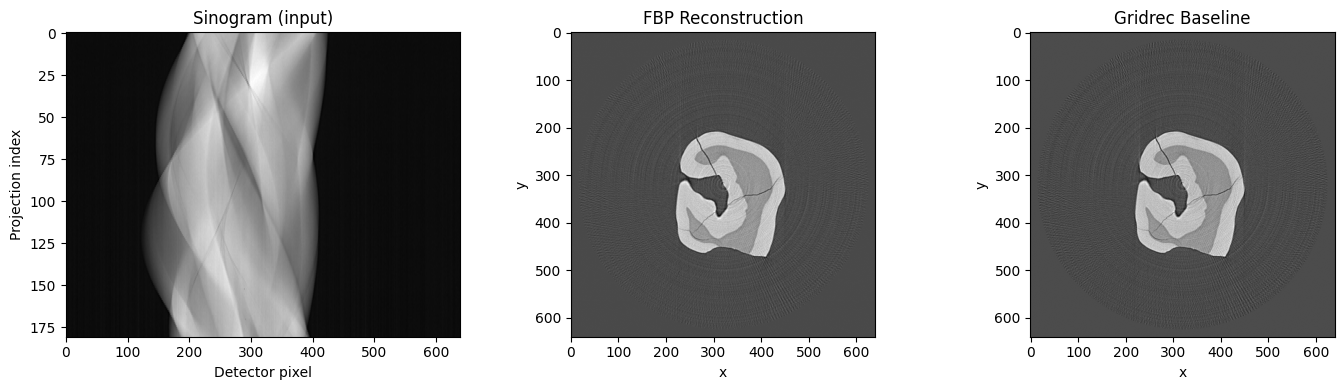

In [5]:
# --- Uncomment to run reconstruction from scratch ---
# sino = sinogram_data[:, 0, :]
# sino_shifted = _shift_sinogram(sino, rot_center, 640)
# recon_fbp = filtered_back_projection(sino_shifted, obs['theta'], 640)
# recon_fbp = circular_mask(recon_fbp, ratio=0.95)

# Load precomputed reconstructions
ref_dir = os.path.join(TASK_DIR, "evaluation", "reference_outputs")
recon_gridrec = np.load(os.path.join(ref_dir, "reconstruction.npy"))  # gridrec baseline
recon_fbp = np.load(os.path.join(TASK_DIR, "output", "reconstruction.npy"))  # our FBP

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

plot_sinogram(sinogram_data[:, 0, :], ax=axes[0], title="Sinogram (input)")
plot_reconstruction(recon_fbp[0], ax=axes[1], title="FBP Reconstruction")
plot_reconstruction(recon_gridrec[0], ax=axes[2], title="Gridrec Baseline")

plt.tight_layout()
plt.show()

## 5. Quantitative Evaluation

We compare the FBP reconstruction against the gridrec baseline using:
- **NCC** (Normalised Cross-Correlation): cosine similarity between flattened vectors
- **NRMSE** (Normalised Root Mean Square Error): RMSE divided by the dynamic range of the reference

In [6]:
metrics = compute_metrics(recon_fbp[0], recon_gridrec[0])

print("FBP vs Gridrec Baseline")
print("=" * 35)
print(f"  NCC:   {metrics['ncc']:.4f}  (threshold: >= 0.8837)")
print(f"  NRMSE: {metrics['nrmse']:.4f}  (threshold: <= 0.0323)")
print()
if metrics['ncc'] >= 0.8837 and metrics['nrmse'] <= 0.0323:
    print("PASS: Both metrics within acceptable bounds.")
else:
    print("FAIL: One or more metrics outside acceptable bounds.")

FBP vs Gridrec Baseline
  NCC:   0.9819  (threshold: >= 0.8837)
  NRMSE: 0.0294  (threshold: <= 0.0323)

PASS: Both metrics within acceptable bounds.


## 6. Difference Map

The difference between FBP and gridrec is small and primarily at high-frequency features, reflecting the different interpolation strategies (pixel-driven back-projection vs. gridding in Fourier space).

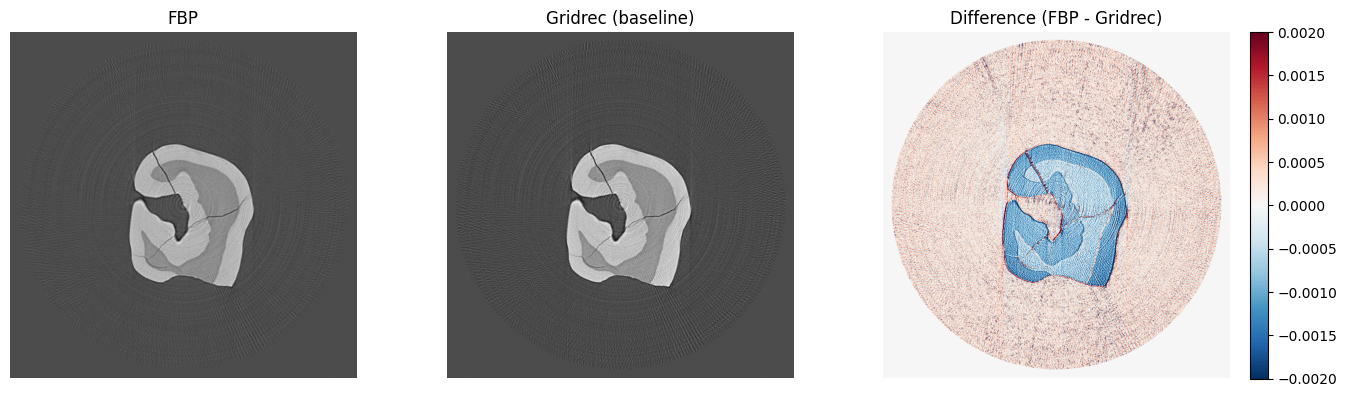

Max absolute difference: 0.006621
Mean absolute difference: 0.000354


In [7]:
diff = recon_fbp[0] - recon_gridrec[0]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
vmin, vmax = recon_gridrec[0].min(), recon_gridrec[0].max()

im0 = axes[0].imshow(recon_fbp[0], cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title("FBP"); axes[0].axis('off')

im1 = axes[1].imshow(recon_gridrec[0], cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title("Gridrec (baseline)"); axes[1].axis('off')

im2 = axes[2].imshow(diff, cmap='RdBu_r', vmin=-0.002, vmax=0.002)
axes[2].set_title("Difference (FBP - Gridrec)"); axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

print(f"Max absolute difference: {np.abs(diff).max():.6f}")
print(f"Mean absolute difference: {np.abs(diff).mean():.6f}")